In [9]:
!pip install gdown

In [10]:
import gdown
gdown.download("https://drive.google.com/uc?id=1CkUp_wtuauTNL9aOW-K52jDlTXqD4KWS", output="file_name", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1CkUp_wtuauTNL9aOW-K52jDlTXqD4KWS
To: C:\Users\user\file_name
100%|██████████████████████████████████████████████████████████████████████████████| 23.8k/23.8k [00:00<00:00, 954kB/s]


'file_name'

In [15]:
import pandas as pd

df = pd.read_csv('C:\\Users\\user\\Downloads\\diabetes.csv')

In [16]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [18]:
import pandas as pd

df = pd.read_csv('C:\\Users\\user\\Downloads\\diabetes.csv')
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_data_summary = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
print(missing_data_summary)

                          Missing Values  Percentage
Pregnancies                           14    1.822917
Glucose                                0    0.000000
BloodPressure                          0    0.000000
SkinThickness                          8    1.041667
Insulin                                0    0.000000
BMI                                   10    1.302083
DiabetesPedigreeFunction               0    0.000000
Age                                    0    0.000000
Outcome                                0    0.000000


In [19]:
!pip install missingno

In [20]:
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

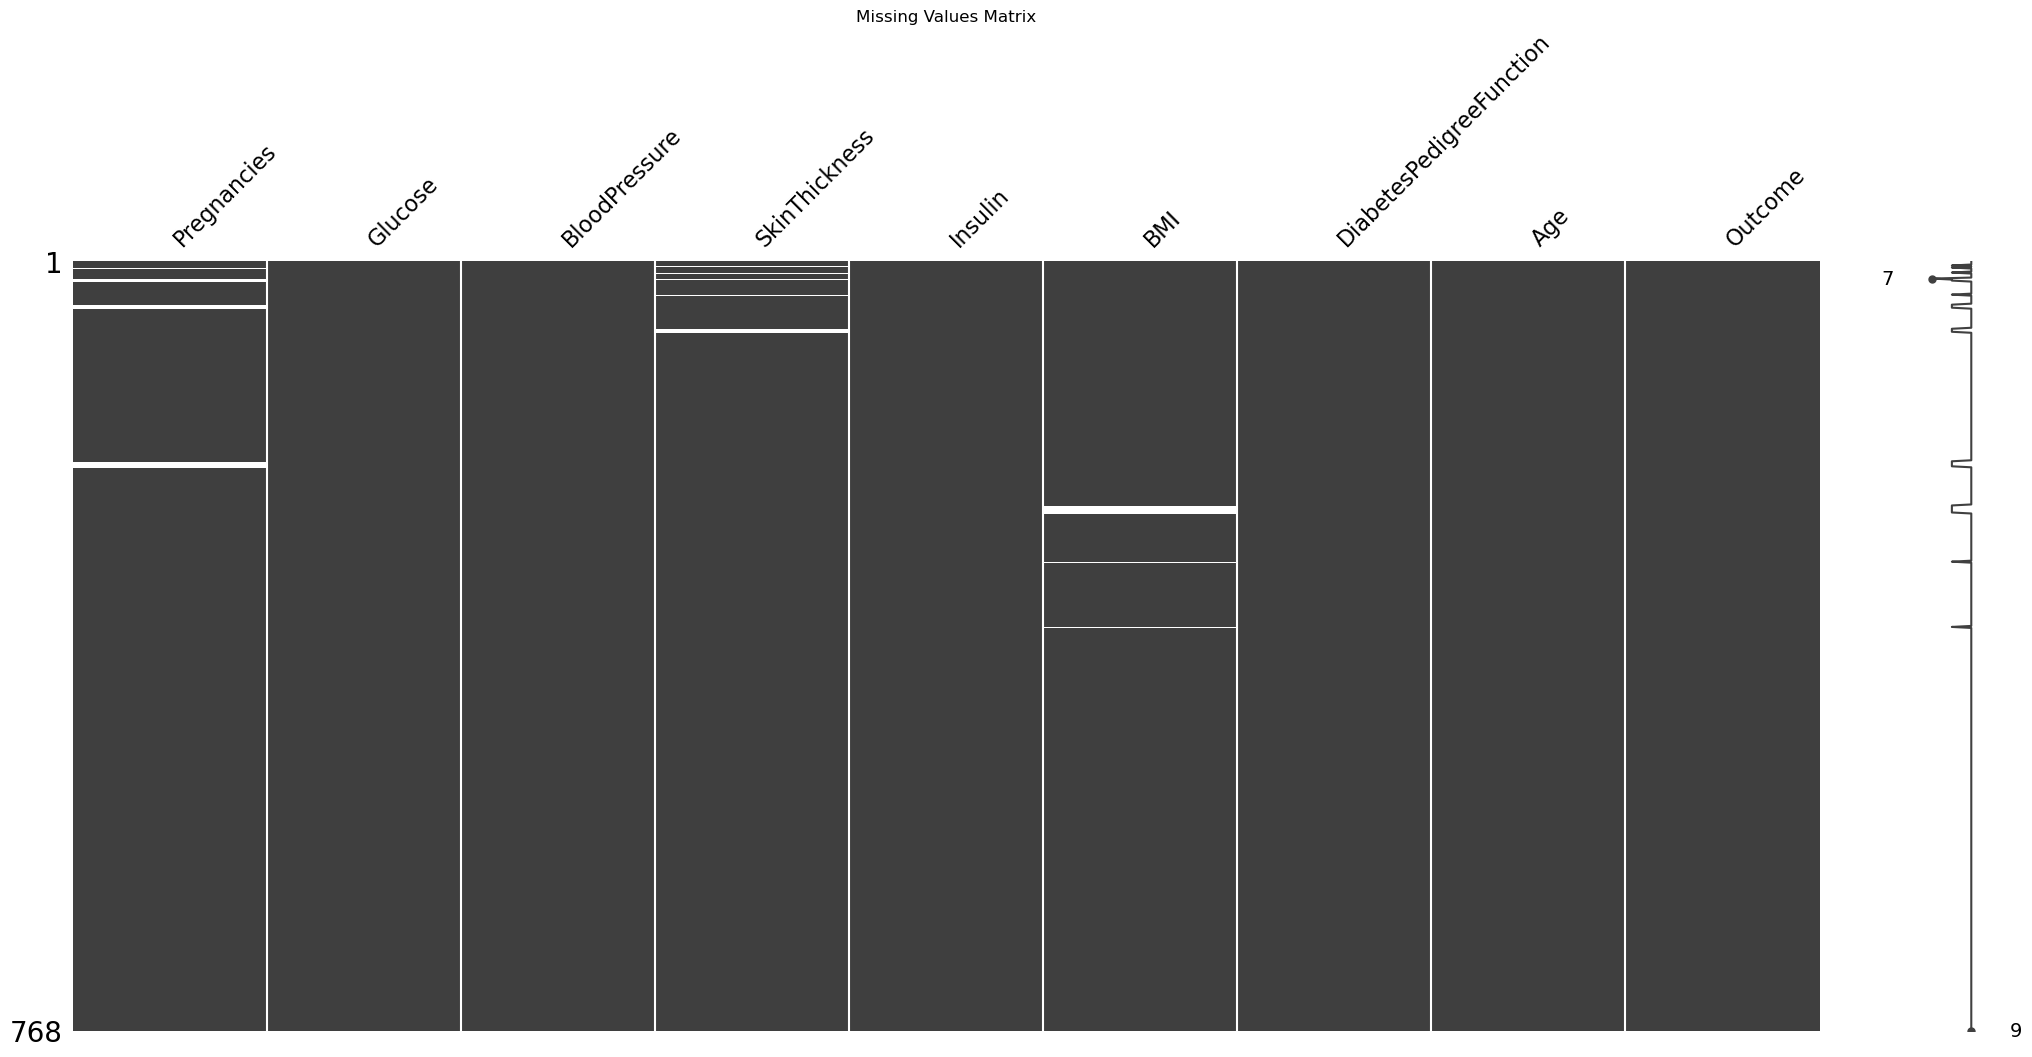

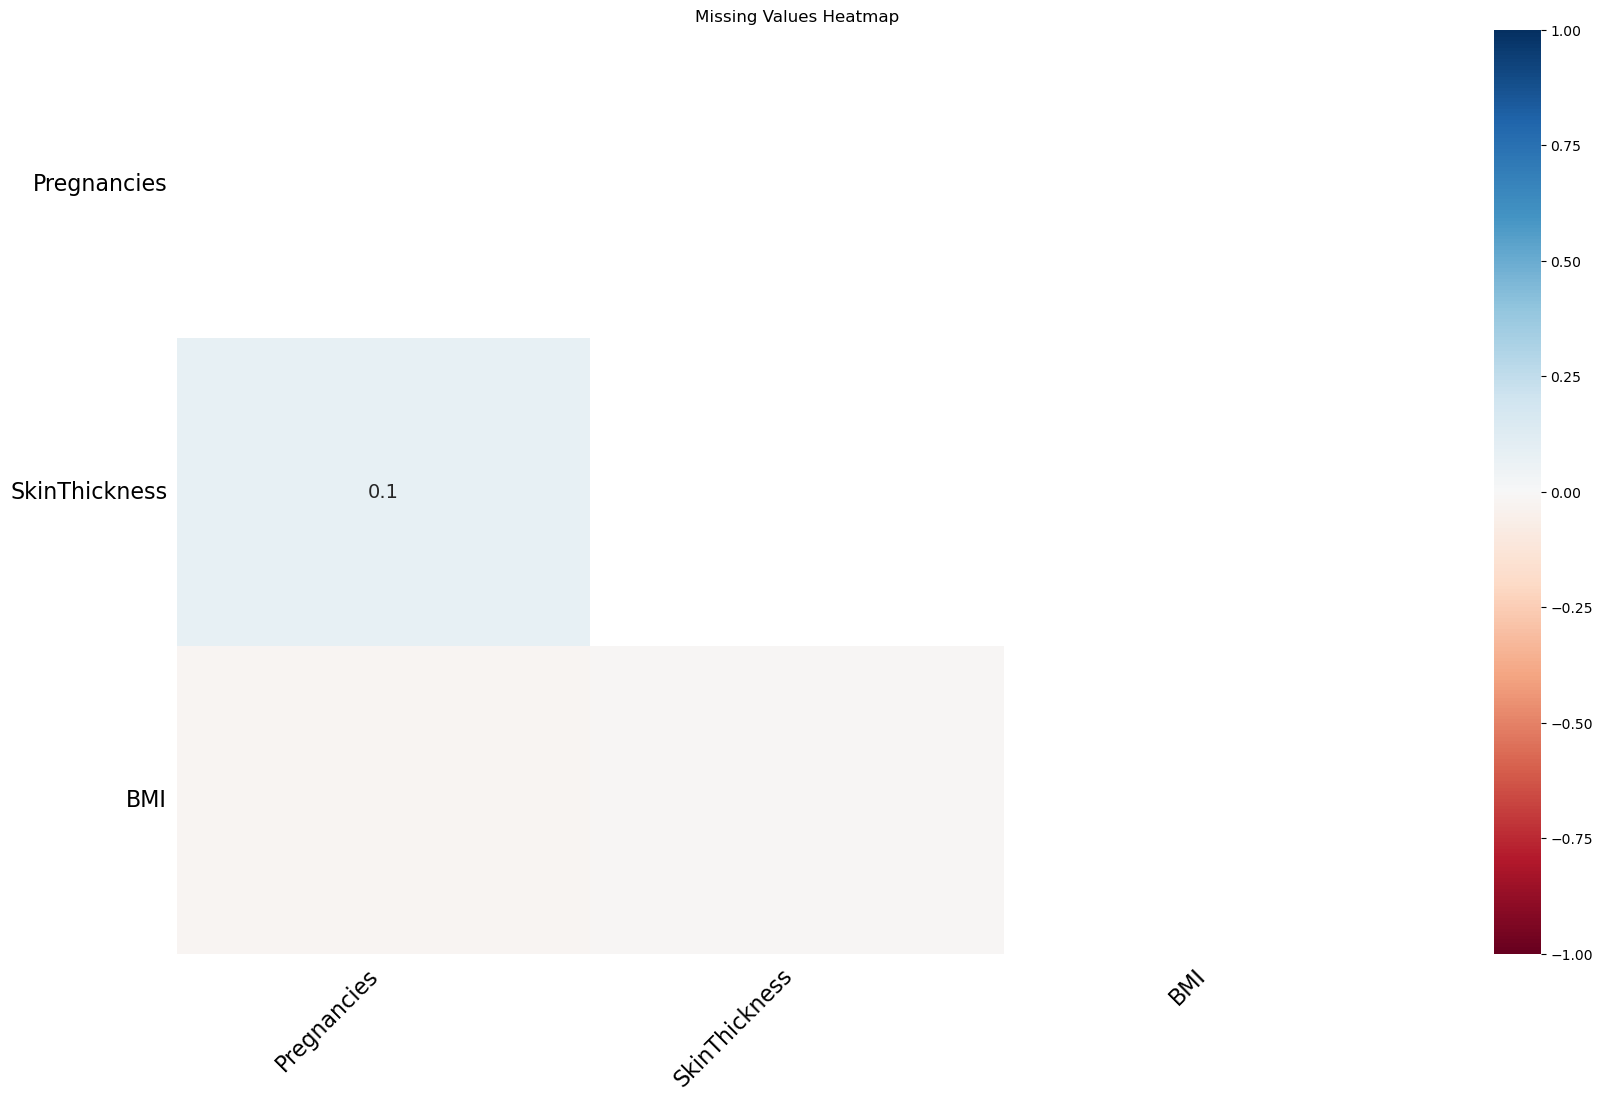

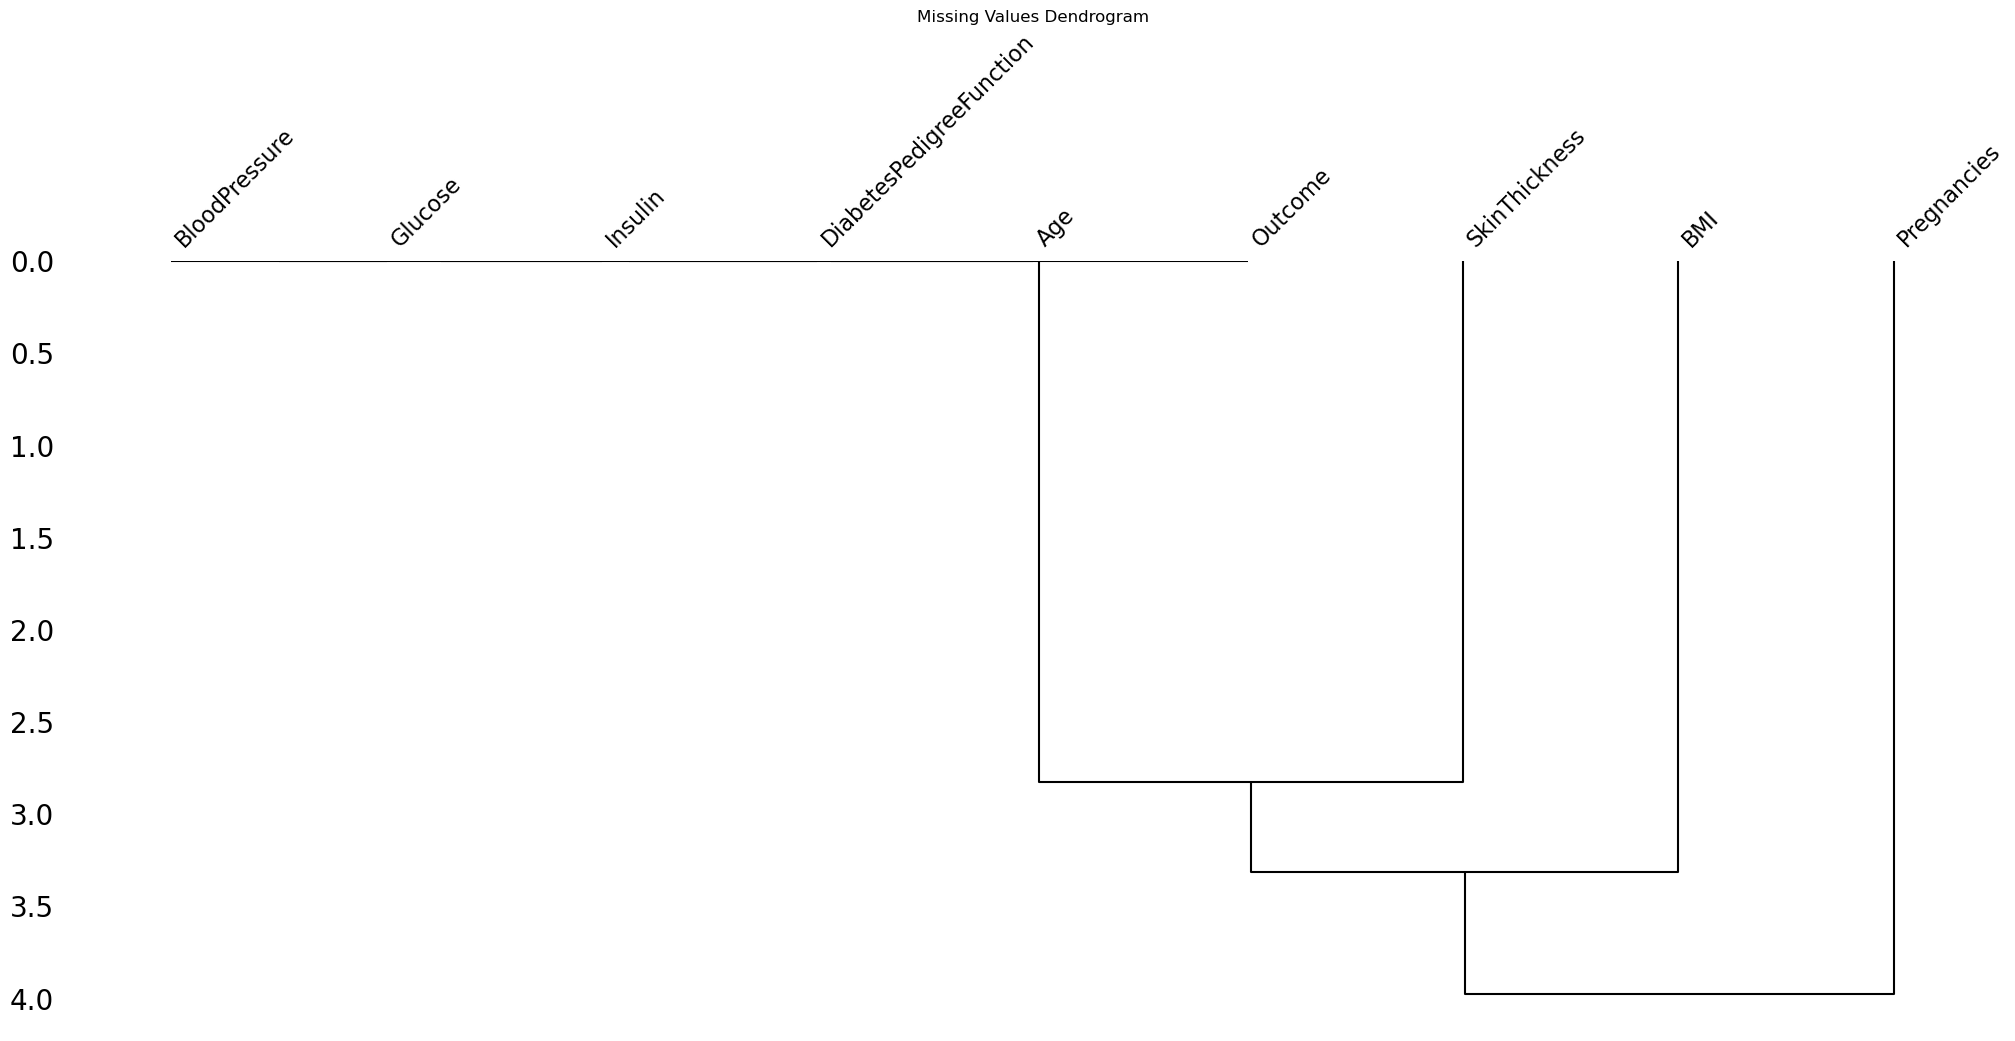

In [22]:
df = pd.read_csv('C:\\Users\\user\\Downloads\\diabetes.csv')
msno.matrix(df)
plt.title("Missing Values Matrix")
plt.show()
msno.heatmap(df)
plt.title("Missing Values Heatmap")
plt.show()
msno.dendrogram(df)
plt.title("Missing Values Dendrogram")
plt.show()

In [23]:
import pandas as pd
from sklearn.impute import SimpleImputer
df = pd.read_csv('C:\\Users\\user\\Downloads\\diabetes.csv')
missing_values = df.isnull().sum()
print("Missing values before handling:\n", missing_values)
numerical_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
imputer = SimpleImputer(strategy='mean')
df[numerical_columns] = imputer.fit_transform(df[numerical_columns])
missing_values_after = df.isnull().sum()
print("\nMissing values after handling:\n", missing_values_after)

Missing values before handling:
 Pregnancies                 14
Glucose                      0
BloodPressure                0
SkinThickness                8
Insulin                      0
BMI                         10
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64

Missing values after handling:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [25]:
df.to_csv('C:\\Users\\user\\Downloads\\diabetes.csv', index=False)


In [26]:
print("First rows of the cleaned dataset:\n", df.head())


First rows of the cleaned dataset:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0      0.0  33.6   
1          1.0     85.0           66.0           29.0      0.0  26.6   
2          8.0    183.0           64.0            0.0      0.0  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          0.0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction   Age  Outcome  
0                     0.627  50.0        1  
1                     0.351  31.0        0  
2                     0.672  32.0        1  
3                     0.167  21.0        0  
4                     2.288  33.0        1  


In [27]:
from sklearn.model_selection import train_test_split
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])


Training set size: 614
Testing set size: 154


In [28]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print("KNN model trained successfully.")

KNN model trained successfully.


In [29]:
y_pred = knn.predict(X_test)
print("Predicted outcomes for X_test:\n", y_pred)

Predicted outcomes for X_test:
 [0 0 0 1 1 1 0 0 1 1 0 1 0 0 0 1 0 0 1 0 1 0 1 0 1 1 0 0 0 0 1 1 1 1 0 0 1
 0 0 1 0 1 1 1 0 0 0 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 1 0 0 1 0 1 0
 1 0 1 1 0 1 0 0 1 0 0 0 0 1 1 0 1 1 1 1 0 0 1 1 1 0 1 1 0 0 0 0 1 0 0 0 0
 1 1 0 0 0 0]


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
precision = precision_score(y_test, y_pred)
print("Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", class_report)

Accuracy: 0.6688311688311688
Precision: 0.532258064516129
Recall: 0.6
F1 Score: 0.5641025641025641
Confusion Matrix:
 [[70 29]
 [22 33]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.71      0.73        99
           1       0.53      0.60      0.56        55

    accuracy                           0.67       154
   macro avg       0.65      0.65      0.65       154
weighted avg       0.68      0.67      0.67       154

